In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense as ham
from quant_rotor.Hamiltonian_models.Dense.operators import heisenberg_operators ,rotor_operators

from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme
from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal_dense import integration_scheme as integration_scheme_fast
import quant_rotor.CCC_integration_methods.Dense.thermofield_boltz_funcs as bz

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic import t_periodic

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_exact import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy, intermediate_normalisation

from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import Z as Z_stat

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_sub_class import (
    QuantumSimulation,
    SimulationParams,
    TensorData,
)

In [2]:
np.set_printoptions(precision=10)
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)

# One electron TF

In [3]:
state = 3
state_2 = state**2
site = 2

p = state
i = 1
a = p - i

g = 0.1
periodic = False

beta = 0

In [4]:
K, V = rotor_operators(state, g)
H = ham(site, K, V, V, periodic)

In [5]:
eig_val, eig_vec = np.linalg.eigh(H)

In [6]:
u_vec = np.exp((-np.diag(K) * beta) / 2)

In [7]:
physical_hilbert_dim = state

In [8]:
diagonal_vecs = []

for n in range(physical_hilbert_dim):
    print(-(1 / np.sqrt(physical_hilbert_dim)) * np.copy(u_vec))
    diagonal_vec = -(1/np.sqrt(physical_hilbert_dim))*np.copy(u_vec)
    diagonal_vec[n] +=  1
    diagonal_vecs.append(diagonal_vec)

diagonal_vecs = np.array(diagonal_vecs)

# The diagonal basis is now over-complete we need to use a lowdin procedure
overlap_matrix = diagonal_vecs.T@diagonal_vecs
eig_vals_lowdin,eig_vecs_lowdin = np.linalg.eigh(overlap_matrix)

# Check for eigenvalues that are zero they are linear dependent and can be removed
# this hardcoded because the there should only be 1 excess basis vector and all other eigenvalues will be 1
linearly_independent_eigvals = eig_vals_lowdin[1:]
print(linearly_independent_eigvals)

# Remove linear dependent vector from set of eigenvectors
# Columns of eigh output are the eigenvectors
linearly_independent_vecs = eig_vecs_lowdin[:,1:]

# Find the reduced basis set
# Note: columns are basis vectors
# Reduced basis written C_{m\lambda}
reduced_basis = diagonal_vecs@linearly_independent_vecs

# Create diagonal state basis including
# Diagonal basis as C_{m\lambda}
diagonal_basis = np.zeros((physical_hilbert_dim, physical_hilbert_dim))
diagonal_basis[:,0] = u_vec
diagonal_basis[:,1:] = reduced_basis

[-0.5773502692+0.j -0.5773502692+0.j -0.5773502692+0.j]
[-0.5773502692+0.j -0.5773502692+0.j -0.5773502692+0.j]
[-0.5773502692+0.j -0.5773502692+0.j -0.5773502692+0.j]
[1. 1.]


/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/407005271.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  diagonal_basis[:,0] = u_vec
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/407005271.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  diagonal_basis[:,1:] = reduced_basis


In [9]:
U, _, U_vec = bz.thermofield_change_of_basis_new(K, beta)

# U, Q= bz.thermofield_change_of_basis(K)

I = np.eye(state)

K_prim = np.zeros((state_2, state_2), dtype=complex)

# for i in range(1, state):
#     K_prim[state * i + i, state * i + i] = 1

K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

K_tilda = U.T @ K_prim @ U

V_tensor = V.reshape(state, state, state, state)

V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/quant_rotor/CCC_integration_methods/Dense/thermofield_boltz_funcs.py:150: ComplexWarning: Casting complex values to real discards the imaginary part
  v = np.asarray(v, dtype=float)


In [10]:
eig_val, eig_vec = np.linalg.eigh(K_tilda)

In [11]:
V_vec = np.exp((np.diag(K) * beta) / 2)

In [12]:
p = state_2
i = 1
a = p - i

In [13]:
V_m = np.zeros((state_2), dtype=complex)

In [14]:
for x in range(state):
    V_m[x * state + x] += V_vec[x]

In [15]:
V_p = V_m @ U

In [16]:
t_a_i_tensor = np.zeros((2, a, i), dtype=complex)
t_ab_ij_tensor = np.zeros((2, 2, a, a, i, i), dtype=complex)

for i in range(2):
    t_a_i_tensor[i] = V_p.reshape(state_2, 1)[1:, :]

In [17]:
V_0 = V_p[0]

In [18]:
t_a_i_tensor = t_a_i_tensor / V_0

In [19]:
def A_term(a_upper, a_site):
    return np.hstack((-t_a_i_tensor[a_site], np.identity(a_upper)))

def B_term(b_lower, b_site):
    return np.vstack((np.identity(b_lower), t_a_i_tensor[b_site]))

In [20]:
R_single = np.einsum("ap, pq, qi->ai", A_term(a, 0), K_tilda, B_term(i, 0))

# Initialization Primitive Rotor

In [21]:
p = state
i = 1
a = p - i

g = 0.3
periodic = False

beta = 0

In [22]:
np.exp((-np.diag(K) * beta) / 2)

array([1.+0.j, 1.+0.j, 1.+0.j])

In [23]:
np.exp((np.diag(K) * beta) / 2)

array([1.+0.j, 1.+0.j, 1.+0.j])

In [24]:
eig_val, eig_vec = np.linalg.eigh(H)

In [25]:
def U_func(beta):
    U, U_vec, factor_n = bz.thermofield_change_of_basis_new(K, beta)

    # U, Q= bz.thermofield_change_of_basis(K)

    I = np.eye(state)

    K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

    K_tilda = U.T @ K_prim @ U

    V_tensor = V.reshape(state, state, state, state)

    V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

    V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

    V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

    return U, K_tilda, V_tilda, factor_n

In [26]:
p = state_2
i = 1
a = p - i

In [27]:
def V_p_func(U):
    V_vec = np.exp((np.diag(K) * beta) / 2)

    V_m = np.zeros((state_2), dtype=complex)

    for x in range(state):
        V_m[x * state + x] += V_vec[x]

    V_p = V_m @ U

    return V_p

In [28]:
t_a_i_tensor = np.zeros((site, a, i), dtype=complex)
t_ab_ij_tensor = np.zeros((site, site, a, a, i, i), dtype=complex)

In [29]:
V_p.shape

(9,)

In [30]:
for i in range(site):
    t_a_i_tensor[i] = V_p.reshape(state_2, 1)[1:, :]

In [31]:
t_a_i_tensor = t_a_i_tensor / V_p[0]

In [32]:
time_TF, energy_TF, t_0_TF, t_1_TF, t_2_TF = integration_scheme_fast(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), periodic=periodic, import_guess=True, t_0_import=np.log(V_p[0])*site, t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

In [33]:
time_CCC, energy_CCC, t_0_CCC, t_1_CCC, t_2_CCC = integration_scheme_fast(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), periodic=periodic)

In [34]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])

In [35]:
# ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])

In [36]:
# def Z_new(t_0, factor_n):
#     return np.exp(t_0) * (factor_n**2)**site

In [37]:
# Z_val = np.array([Z_new(x) for x in t_0_TF])

In [76]:
beta_array = np.array([0.001, 2, 5, 10])
TF_array = []
val_array = []
t_amp = []

In [77]:
for beta_idx in range(beta_array.shape[0]):

    beta = beta_array[beta_idx]

    p = state_2
    i = 1
    a = p - i

    U, K_tilda, V_tilda, factor_n = U_func(beta)

    H_TF = ham(site, K_tilda, V_tilda, V_tilda, periodic)

    eig_val_TF, _ = np.linalg.eigh(H_TF)

    V_p = V_p_func(U)

    t_a_i_tensor = np.zeros((site, a, i), dtype=complex)
    t_ab_ij_tensor = np.zeros((site, site, a, a, i, i), dtype=complex)

    for i in range(site):
        t_a_i_tensor[i] = V_p.reshape(state_2, 1)[1:, :]

    t_a_i_tensor = t_a_i_tensor / V_p[0]

    time_TF, energy_TF, t_0_TF, t_1, t_2 = integration_scheme_fast(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), t_final=40, periodic=periodic, import_guess=True, t_0_import=0, t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

    ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])
    # ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])
    # Z_val = np.array([Z_new(x, factor_n) for x in t_0_TD_TF_CC])

    TF_array.append((time_TF, energy_TF, t_0_TF))
    val_array.append(ED_U_val)
    t_amp.append((t_1, t_2))

    E = amplitute_energy(site, state_2, periodic, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), t_1.reshape(site, a, 1), t_2.reshape(site, site, a, a, 1, 1))
    print("Energy:", E)


0.0
0.00042981117635397385
0.004727922939893712
0.0477090405752911
0.34933071086122913
0.669551255990021
0.9950719486629196
1.319790350491033
1.6392386138609605
1.9742281221817235
2.250757697498214
2.5272872728147044
2.8135117234580647
3.146710030477096
3.542734275385305
3.965054833766709
4.360334775948921
4.739845510511557
5.109679295128218
5.467689253868982
5.8569751150976845
6.322728412235138
6.822728412235138
7.322728412235138
7.822728412235138
8.322728412235138
8.822728412235138
9.322728412235138
9.822728412235138
10.322728412235138
10.822728412235138
11.322728412235138
11.822728412235138
12.322728412235138
12.822728412235138
13.322728412235138
13.822728412235138
14.322728412235138
14.822728412235138
15.322728412235138
15.822728412235138
16.322728412235136
16.822728412235136
17.322728412235136
17.822728412235136
18.322728412235136
18.822728412235136
19.322728412235136
19.822728412235136
20.322728412235136
20.822728412235136
21.322728412235136
21.822728412235136
22.322728412235136


In [30]:
U, K_tilda, V_tilda, factor_n = U_func(0)

H_TF = ham(site, K_tilda, V_tilda, V_tilda, periodic)

eig_val_TF, eig_vec_TF = np.linalg.eigh(H_TF)

In [31]:
tau_arr = np.arange(0, 40.5, 0.5)
energy_arr = np.zeros_like(tau_arr)

In [32]:
W = eig_vec_TF

th =  np.zeros((81))
th[0] = 1

In [33]:
for tau_idx in range(tau_arr.shape[0]):

    tau_val = tau_arr[tau_idx]

    exp_term = np.zeros((81,81))

    for i in range(81):
        exp_term[i, i] = np.exp(-eig_val_TF[i] * tau_val)

    gs = (W @ exp_term) @ (W.T @ th)
    ev = np.zeros((81, 2))
    ev[:, 0] = gs
    ev[:, 1] = gs

    t_1 = t_1_amplitude_guess_ground_state(state_2, site, ev, [0, 1])
    t_2 = t_2_amplitude_guess_ground_state(state_2, site, ev, [0, 1])

    E = amplitute_energy(site, state_2, periodic, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2) ,V_tilda.reshape(state_2, state_2, state_2, state_2), t_1.reshape(site, a, 1), t_2.reshape(site, site, a, a, 1, 1))

    energy_arr[tau_idx] = E

/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/2837723221.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 0] = gs
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/2837723221.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 1] = gs
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/2837723221.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_arr[tau_idx] = E


In [34]:
dt = 1e-5
t = 3

In [35]:
tau_0 = t - dt

exp_term = np.zeros((81,81))

for i in range(81):
    exp_term[i, i] = np.exp(-eig_val_TF[i] * tau_0)

gs = (W @ exp_term) @ (W.T @ th)
ev = np.zeros((81, 2))
ev[:, 0] = gs
ev[:, 1] = gs

t_1_0 = t_1_amplitude_guess_ground_state(state_2, site, ev, [0, 1])
t_2_0 = t_2_amplitude_guess_ground_state(state_2, site, ev, [0, 1])

# E = amplitute_energy(site, state_2, periodic, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2) ,V_tilda.reshape(state_2, state_2, state_2, state_2), t_1.reshape(site, a, 1), t_2.reshape(site, site, a, a, 1, 1))

/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/4172700879.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 0] = gs
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/4172700879.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 1] = gs


In [36]:
tau_1 = t + 0.00001

exp_term = np.zeros((81,81))

for i in range(81):
    exp_term[i, i] = np.exp(-eig_val_TF[i] * tau_1)

gs = (W @ exp_term) @ (W.T @ th)
ev = np.zeros((81, 2))
ev[:, 0] = gs
ev[:, 1] = gs

t_1_1 = t_1_amplitude_guess_ground_state(state_2, site, ev, [0, 1])
t_2_1 = t_2_amplitude_guess_ground_state(state_2, site, ev, [0, 1])

# E = amplitute_energy(site, state_2, periodic, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2) ,V_tilda.reshape(state_2, state_2, state_2, state_2), t_1.reshape(site, a, 1), t_2.reshape(site, site, a, a, 1, 1))

/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/1019042359.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 0] = gs
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/1019042359.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 1] = gs


In [37]:
dt_1_dt =  (t_1_1 - t_1_0)/(2*dt)
dt_2_dt =  (t_2_1 - t_2_0)/(2*dt)

In [38]:
tau = t

exp_term = np.zeros((81,81))

for i in range(81):
    exp_term[i, i] = np.exp(-eig_val_TF[i] * tau)

gs = (W @ exp_term) @ (W.T @ th)
ev = np.zeros((81, 2))
ev[:, 0] = gs
ev[:, 1] = gs

t_1 = t_1_amplitude_guess_ground_state(state_2, site, ev, [0, 1])
t_2 = t_2_amplitude_guess_ground_state(state_2, site, ev, [0, 1])


/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/651674071.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 0] = gs
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_6661/651674071.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  ev[:, 1] = gs


In [39]:
dt_1_dt_new =  (t_1_1 - t_1)/(dt)
dt_2_dt_new =  (t_2_1 - t_2)/(dt)

In [40]:
T_1_e, T_2_e, R_1_e, R_2_e = t_periodic(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), "original", Import_t=True, t_1_import=np.copy(t_1.reshape(site, a, 1)), t_2_import=np.copy(t_2.reshape(site, site, a, a, 1, 1)), periodic=periodic, one_cicle=True)

original


In [41]:
np.max(np.abs(R_1_e + dt_1_dt))

np.float64(1.138464322814059e-11)

In [42]:
np.max(np.abs(R_2_e + dt_2_dt))

np.float64(1.9536004758347048e-11)

In [43]:
site

2

In [44]:
time_TF, energy_TF, t_0_TF, t_1_TF, t_2_TF = integration_scheme_fast(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), t_init=tau, t_final=40, periodic=periodic, import_guess=True, t_0_import=0, t_1_import=np.copy(t_1.reshape(site, a)), t_2_import=np.copy(t_2.reshape(site, site, a, a)))

3.0
3.0314091395078306
3.345500534586137
3.7526896520704685
4.152029970390315
4.537018459235698
4.916246830228706
5.29334711034493
5.679833904110194
6.113989605010584
6.613989605010584
7.113989605010584
7.613989605010584
8.113989605010584
8.613989605010584
9.113989605010584
9.613989605010584
10.113989605010584
10.613989605010584
11.113989605010584
11.613989605010584
12.113989605010584
12.613989605010584
13.113989605010584
13.613989605010584
14.113989605010584
14.613989605010584
15.113989605010584
15.613989605010584
16.113989605010584
16.613989605010584
17.113989605010584
17.613989605010584
18.113989605010584
18.613989605010584
19.113989605010584
19.613989605010584
20.113989605010584
20.613989605010584
21.113989605010584
21.613989605010584
22.113989605010584
22.613989605010584
23.113989605010584
23.613989605010584
24.113989605010584
24.613989605010584
25.113989605010584
25.613989605010584
26.113989605010584
26.613989605010584
27.113989605010584
27.613989605010584
28.113989605010584
28.6

In [45]:
T_1_e, T_2_e, R_1_e, R_2_e = t_periodic(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), "original", Import_t=True, t_1_import=np.copy(t_1_TF.reshape(site, a, 1)), t_2_import=np.copy(t_2_TF.reshape(site, site, a, a, 1, 1)*0), periodic=periodic, one_cicle=True)

original


In [46]:
time = np.arange(0, 40.5, 0.5)

In [47]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time])

In [48]:
eig_val_TF[0] - ED_U_val[-1]

np.float64(-9.679756995950584e-16)

In [49]:
eig_val_TF[0] - (energy_TF[-1])

np.complex128(-9.471590178833367e-16+0j)

In [50]:
eig_val_TF[0] - ED_U_val[-1]

np.float64(-9.679756995950584e-16)

In [51]:
energy_arr - ED_U_val

array([ 0.,  0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,  0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,  0., -0.,  0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.])

In [57]:
energy_arr[-1] - energy_TF[-1]

np.complex128(-5.585809592645319e-16+0j)

In [52]:
shift = 0

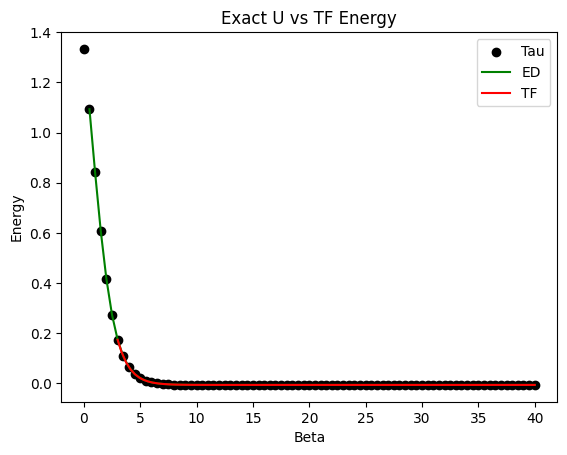

In [55]:
plt.scatter(tau_arr, energy_arr, label="Tau", color="black")
plt.plot(time[time > shift], ED_U_val[time > shift], color="green", label="ED")
plt.plot(time_TF[time_TF > shift], energy_TF[time_TF > shift], color="red", label="TF")
# plt.plot(TF_array[0][0], TF_array[0][1], label=f"TF beta = {0.001}")
plt.title("Exact U vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

(0.0015763879673301503+0j)


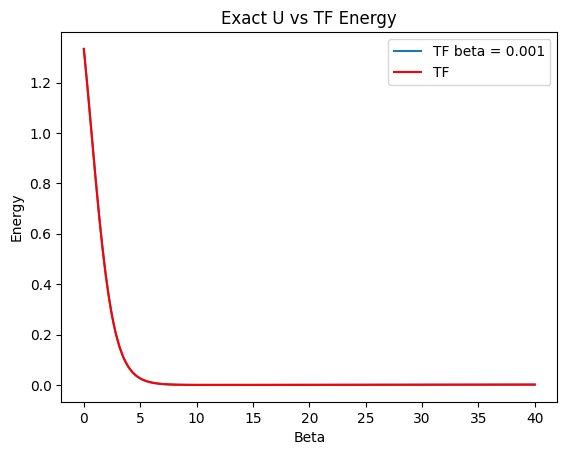

In [70]:
for beta_idx in range(1):
    plt.plot(TF_array[beta_idx][0], TF_array[beta_idx][1], label=f"TF beta = {beta_array[beta_idx]}")
    print(TF_array[beta_idx][1][-1])
    # plt.plot(TF_array[beta_idx][0], val_array[beta_idx], label=f"Exact U beta = {beta_array[beta_idx]}", linestyle="--")
# plt.plot(time_CCC, energy_CCC, label=f"CCC")
plt.plot(time_TF[time_TF > shift], energy_TF[time_TF > shift], color="red", label="TF")
plt.title("Exact U vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [87]:
TF_array[beta_idx][1][-1] - energy_TF[-1]

np.complex128(5.719581685691491e-05+0j)

In [86]:
energy_TF[-1]

np.complex128(0.0015191921505194085+0j)

In [41]:
val_array[0][-1]

np.float64(-0.006230571980708759)

In [ ]:
energy_CCC[-1]

np.complex128(-0.006230589863532542+0j)

In [69]:
eig_val_TF[0] + 0.00623057996738673

np.float64(-9.907519599866577e-09)

In [ ]:
# for beta_idx in range(beta_array.shape[0]):
#     plt.plot(TF_array[0, 0][:y_trimmed.shape[0]][shift_array], val_array[2, 0][:y_trimmed.shape[0]][shift_array], label=f"Z beta = {beta_array[beta_idx]}", linestyle="--")
# plt.plot(TF_array[0, 0][:y_trimmed.shape[0]][shift_array], val_array[1, 0][:y_trimmed.shape[0]][shift_array], label=f"Exact Z")
# plt.title("Exact Z vs Z_new")
# plt.xlabel("Beta")
# plt.ylabel("Z")
# plt.legend()
# plt.show()

In [ ]:
U, vec= bz.thermofield_change_of_basis(K)

I = np.eye(state)

K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

K_tilda = U.T @ K_prim @ U

V_tensor = V.reshape(state, state, state, state)

V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

[0.5773502692 0.5773502692 0.5773502692]
[1. 1.]


In [ ]:
time_TF_old, energy_TD_TF_CCC_old, one_max_TD_TF_CC_old, two_max_TD_TF_CC_old = integration_scheme(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), periodic=periodic, t_init=0, t_final=10, nof_points=10000)

Single (0.6666666666666666+0j)
Double 0j
Double 0j
Single (0.6666666666666666+0j)
Double 0j
Single (0.6666666666666666+0j)
Single (0.6666549777440092+0j)
Double (-2.922230664375985e-07+0j)
Double 0j
Single (0.6666549777440092+0j)
Double (-2.922230664375985e-07+0j)
Single (0.6666549777440092+0j)
Single (0.6666491330492419+0j)
Double (-4.3834612750562826e-07+0j)
Double 0j
Single (0.6666491330463601+0j)
Double (-4.3834612750562826e-07+0j)
Single (0.6666491330492419+0j)
Single (0.6666403660654534+0j)
Double (-6.575278372462798e-07+0j)
Double 0j
Single (0.6666403660589688+0j)
Double (-6.5752783724628e-07+0j)
Single (0.6666403660654526+0j)
Single (0.6666040748792991+0j)
Double (-1.564867213432421e-06+0j)
Double 0j
Single (0.6666040748425743+0j)
Double (-1.5648672134324235e-06+0j)
Single (0.6666040748792886+0j)
Single (0.6665925884264013+0j)
Double (-1.8520575961146151e-06+0j)
Double 0j
Single (0.6665925883749619+0j)
Double (-1.852057596114619e-06+0j)
Single (0.6665925884263841+0j)
Single (0.

In [ ]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF_old])

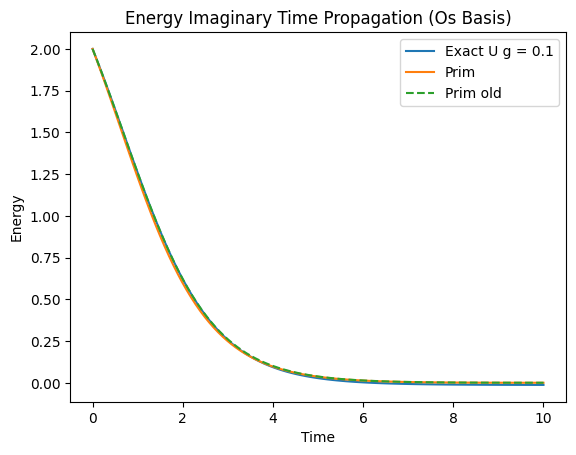

TF (0.0010291989438636281+0j)
Exact:  -0.012127832537906134


In [ ]:
plt.plot(time_TF_old, ED_U_val, label=f"Exact U g = {g}")
plt.plot(time_TF, energy_TD_TF_CCC, label=f"Prim")
plt.plot(time_TF_old, energy_TD_TF_CCC_old, label=f"Prim old", linestyle="--")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TD_TF_CCC_old[-1])
print("Exact: ", ED_U_val[-1])

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


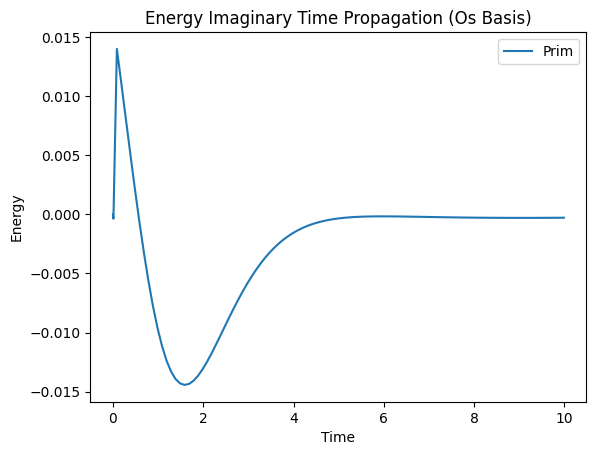

In [ ]:
plt.plot(time_TF[:-1], energy_TD_TF_CCC[:-1] - energy_TD_TF_CCC_old, label=f"Prim")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [ ]:
energy_TD_TF_CCC.shape

(104,)